# Using uv

I used [uv](https://docs.astral.sh/uv/) in order to manage dependencies. This can be installed using your package manager. It is a `cargo`-like dependency management system for python projects.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Data Generation
The following cell makes synthetic data for the testing of the Linear Regression. This is done in order to compare the accuracy of sk-learns model against the implementation on the OS-based kernel-mode-only platform.

Run the cell after the generation cell only once, especially if you want to see what the data looks like. The data here is statically recorded in the Linear Regression in the kernel.

In [3]:
# 1. Generate synthetic data using a linear function: y = 3.5x + 7 + noise
np.random.seed(42)
n_samples = 200

X = np.random.uniform(0, 10, n_samples).reshape(-1, 1)
y = 3.5 * X.squeeze() + 7 + np.random.normal(0, 3, n_samples)  # true: slope=3.5, intercept=7

# 2. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
print("X_train:", X_train.squeeze().tolist())
print("y_train:", y_train.tolist())
print("X_test:",  X_test.squeeze().tolist())
print("y_test:",  y_test.tolist())

X_train: [1.1586905952512971, 8.971102599525771, 6.842330265121569, 4.56069984217036, 3.1800347497186388, 3.492095746126609, 0.46450412719997725, 2.9122914019804194, 3.0087830981676964, 7.29606178338064, 6.334037565104235, 2.2649577519793795, 1.5599452033620265, 8.18014765922493, 1.8657005888603584, 8.154614284548341, 9.624472949421111, 0.2541912674409519, 5.12093058299281, 5.227328293819941, 5.908929431882418, 4.275410183585496, 1.7052412368729153, 8.324426408004218, 8.08397348116461, 5.393422419156507, 0.34388521115218396, 2.418522909004517, 1.195942459383017, 5.187906217433661, 7.7513282336111455, 8.607305832563434, 6.335297107608947, 4.951769101112702, 8.925589984899778, 8.08120379564417, 1.9967378215835974, 9.717820827209607, 0.3142918568673425, 1.6122128725400442, 7.319939418114051, 0.7404465173409036, 3.1171107608941098, 5.5520081159946235, 8.972157579533267, 3.2518332202674705, 6.3230583059357945, 3.0461376917337066, 0.9310276780589921, 2.713490317738959, 2.9214464853521815, 2.

        Linear Regression Results
True function : y = 3.5x + 7 + noise
Learned slope : 3.5314  (true: 3.5)
Learned intercept: 7.0436  (true: 7.0)
MSE           : 9.7616
R² Score      : 0.9035


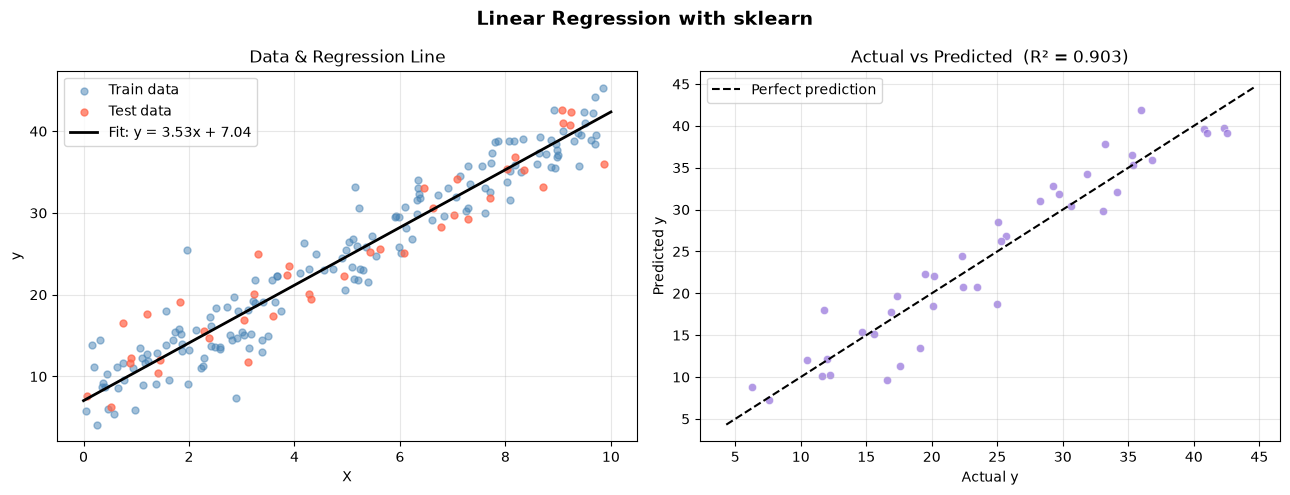

In [4]:
# 3. Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("        Linear Regression Results")
print("=" * 40)
print(f"True function : y = 3.5x + 7 + noise")
print(f"Learned slope : {model.coef_[0]:.4f}  (true: 3.5)")
print(f"Learned intercept: {model.intercept_:.4f}  (true: 7.0)")
print(f"MSE           : {mse:.4f}")
print(f"R² Score      : {r2:.4f}")
print("=" * 40)

# 5. Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear Regression with sklearn", fontsize=14, fontweight="bold")

# --- Plot 1: Data + fit line ---
ax = axes[0]
ax.scatter(X_train, y_train, alpha=0.5, color="steelblue", label="Train data", s=25)
ax.scatter(X_test, y_test, alpha=0.7, color="tomato", label="Test data", s=25)
x_line = np.linspace(0, 10, 300).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color="black", linewidth=2,
        label=f"Fit: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Data & Regression Line")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Actual vs Predicted ---
ax2 = axes[1]
ax2.scatter(y_test, y_pred, color="mediumpurple", alpha=0.7, s=35, edgecolors="white", linewidth=0.5)
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
ax2.plot(lims, lims, "k--", linewidth=1.5, label="Perfect prediction")
ax2.set_xlabel("Actual y")
ax2.set_ylabel("Predicted y")
ax2.set_title(f"Actual vs Predicted  (R² = {r2:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()